In [1]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

C:\Users\princ\AppData\Local\Temp\ipykernel_23692\644160026.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# Step 2: Load dataset
df = pd.read_csv("C:\\Users\\princ\\Downloads\\Oasis\\market analysis\\ifood_df.csv")

In [7]:
# Step 3: Understand data (structure, types, stats)
print(df.shape)

(2205, 39)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [6]:
print(df.describe())

              Income      Kidhome     Teenhome      Recency     MntWines  \
count    2205.000000  2205.000000  2205.000000  2205.000000  2205.000000   
mean    51622.094785     0.442177     0.506576    49.009070   306.164626   
std     20713.063826     0.537132     0.544380    28.932111   337.493839   
min      1730.000000     0.000000     0.000000     0.000000     0.000000   
25%     35196.000000     0.000000     0.000000    24.000000    24.000000   
50%     51287.000000     0.000000     0.000000    49.000000   178.000000   
75%     68281.000000     1.000000     1.000000    74.000000   507.000000   
max    113734.000000     2.000000     2.000000    99.000000  1493.000000   

         MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
count  2205.000000      2205.000000      2205.000000       2205.000000   
mean     26.403175       165.312018        37.756463         27.128345   
std      39.784484       217.784507        54.824635         41.130468   
min       0.000000 

In [8]:
# Step 4: Remove useless columns (no variation)
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [9]:
print(df.shape)

(2205, 37)


In [17]:
# Step 5: Select important features for segmentation
features = ['Income', 'MntTotal', 'NumWebPurchases', 'NumStorePurchases', 'Recency']

In [18]:
df_seg = df[features]

In [19]:
# Step 6: Scale data to bring all features to same level
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_seg)

In [24]:
# Step 7: Apply K-means clustering to create groups
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)
clusters = kmeans.predict(df_scaled)

In [25]:
print(clusters[:10])

[0 2 0 2 1 0 0 2 2 1]


In [29]:
# Step 8: Add cluster labels to dataset
df_seg['Cluster'] = clusters

print(df_seg.head())

    Income  MntTotal  NumWebPurchases  NumStorePurchases  Recency  Cluster
0  58138.0      1529                8                  4       58        0
1  46344.0        21                1                  2       38        2
2  71613.0       734                8                 10       26        0
3  26646.0        48                2                  4       26        2
4  58293.0       407                5                  6       94        1


C:\Users\princ\AppData\Local\Temp\ipykernel_23692\2778116695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seg['Cluster'] = clusters


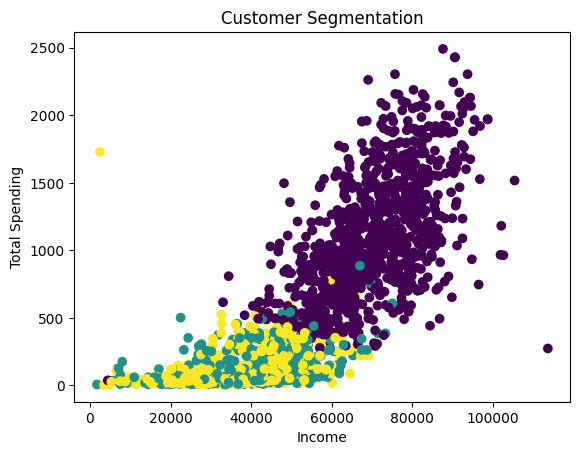

In [22]:
# Step 9: Visualize clusters using scatter plot
plt.scatter(df_seg['Income'], df_seg['MntTotal'], c=df_seg['Cluster'])
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation")
plt.show()

In [23]:
# Step 10: Analyze each cluster using average values
print(df_seg.groupby('Cluster').mean())

               Income     MntTotal  NumWebPurchases  NumStorePurchases  \
Cluster                                                                  
0        69668.659406  1082.088119         5.941584           8.511881   
1        37568.267257   134.387611         2.690265           3.635398   
2        35294.130159   114.377778         2.414286           3.476190   

           Recency  
Cluster             
0        48.730693  
1        76.107965  
2        25.152381  
